#  K-Means Clustering: TMDB Movie Dataset

## Objective
Apply K-Means clustering to segment the TMDB movie catalog into natural groups
based on their principal components (PC1–PC5), previously computed during the
preprocessing stage.

These segments will serve as the foundation for a **content-based recommendation system**:
instead of comparing a movie against all 116,929 entries, we first identify its cluster
and search only within that group — making recommendations faster and more precise.

## Methodology
1. Load the preprocessed dataset
2. Extract PCA components (PC1–PC5)
3. Find the optimal number of clusters using the Elbow Method
4. Apply K-Means with the optimal k
5. Analyze and interpret each cluster
6. Build a recommendation function based on cluster membership

In [78]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from datasets import load_dataset

from sklearn.metrics.pairwise import euclidean_distances



sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120


## 1. Load Dataset

The dataset was preprocessed in a previous stage and is available on HuggingFace.
It contains 116,929 movies with 23 features including metadata, PCA components,
and quality indicators such as `highly_rated` and `duration_bin`.

Key columns for this analysis:
| Column | Description |
|--------|-------------|
| `PC1` to `PC5` | Principal components (93.6% of variance explained) |
| `vote_average` | Average user rating (0–10) |
| `popularity` | TMDB popularity score |
| `release_year` | Year of release |
| `genres` | Movie genres |

In [42]:
ds = load_dataset("pauguzman/tmdb_mineria_datos_processed")
df = ds['train'].to_pandas()


overview = pd.DataFrame({
    'Total movies':   [df.shape[0]],
    'Total features': [df.shape[1]],
    'Missing values': [df.isnull().sum().sum()]
})
print("dataset loaded successfully")
display(overview)

dataset loaded successfully


,Total movies,Total features,Missing values
0,116929,23,39778


## 2. Prepare Data for Clustering

We select the 5 PCA components as input features for K-Means.
These components were chosen because:

- They summarize **93.6% of the original variance** in just 5 dimensions
- They are already **scaled and centered** (no additional normalization needed)
- They are **orthogonal** (no correlation between them), which is ideal for distance-based algorithms

We also keep metadata columns (`title`, `genres`, etc.) to interpret results later —
K-Means only sees the PCA numbers.

In [43]:
PCA_COLS = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
META_COLS = ['title', 'vote_average', 'vote_count', 'popularity', 'genres', 'release_year', 'runtime']

df_clean = df[PCA_COLS + META_COLS].dropna().reset_index(drop=True)
X_pca    = df_clean[PCA_COLS].values

print(f" Data ready for clustering")
print(f"   Movies: {X_pca.shape[0]:,}")
print(f"   Features (PCA components): {X_pca.shape[1]}")
display(df_clean[PCA_COLS].describe().round(2))


 Data ready for clustering
   Movies: 116,929
   Features (PCA components): 5


,PC1,PC2,PC3,PC4,PC5
count,116929.00,116929.00,116929.00,116929.00,116929.00
mean,0.00,0.00,-0.00,-0.00,0.00
std,1.34,1.12,1.04,0.88,0.85
min,-4.04,-4.78,-2.26,-83.89,-11.46
25%,-0.80,-0.69,-0.49,-0.26,-0.44
50%,-0.26,0.24,-0.17,-0.05,-0.05
75%,0.34,0.73,0.32,0.26,0.49
max,38.33,43.12,80.38,20.15,33.64


## 3. Find Optimal K : Elbow Method

K-Means requires us to specify the number of clusters **before** running the algorithm.
To find the best value, we use two complementary methods:

**Elbow Method (Inertia)**
Inertia measures the sum of distances from each movie to its cluster center.
We look for the point where the curve "bends" — adding more clusters stops
providing significant improvement.

**Silhouette Score**
Measures how well each movie fits its assigned cluster vs. neighboring clusters.
- Score near **1** → movie is well placed in its cluster
- Score near **0** → movie is on the border between clusters
- Score near **-1** → movie would fit better in another cluster

We use a random sample of 15,000 movies for speed — results are representative
of the full 116,929-movie dataset.

In [44]:
np.random.seed(42)
idx  = np.random.choice(len(X_pca), size=15000, replace=False)
X    = X_pca[idx]

inertias    = []
silhouettes = []
K_RANGE     = range(2, 11)

print("2 to 10...")
for k in K_RANGE:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl  = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, lbl, sample_size=3000, random_state=42))
    print(f"  k={k} ✓  inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}")

# Results table
elbow_df = pd.DataFrame({
    'k':          list(K_RANGE),
    'Inertia':    [round(i, 1) for i in inertias],
    'Silhouette': [round(s, 4) for s in silhouettes]
})
print("\n Elbow Method Results:")
display(elbow_df.set_index('k'))

2 to 10...
  k=2 ✓  inertia=58,156  silhouette=0.4885
  k=3 ✓  inertia=47,525  silhouette=0.3913
  k=4 ✓  inertia=37,464  silhouette=0.4161
  k=5 ✓  inertia=32,552  silhouette=0.4119
  k=6 ✓  inertia=27,564  silhouette=0.3732
  k=7 ✓  inertia=24,800  silhouette=0.3711
  k=8 ✓  inertia=22,368  silhouette=0.3802
  k=9 ✓  inertia=20,039  silhouette=0.3160
  k=10 ✓  inertia=18,451  silhouette=0.2998

 Elbow Method Results:


,Inertia,Silhouette
k,,
2,58156.4,0.4885
3,47524.8,0.3913
4,37463.6,0.4161
5,32551.7,0.4119
6,27564.1,0.3732
7,24799.8,0.3711
8,22368.1,0.3802
9,20038.6,0.3160
10,18450.8,0.2998


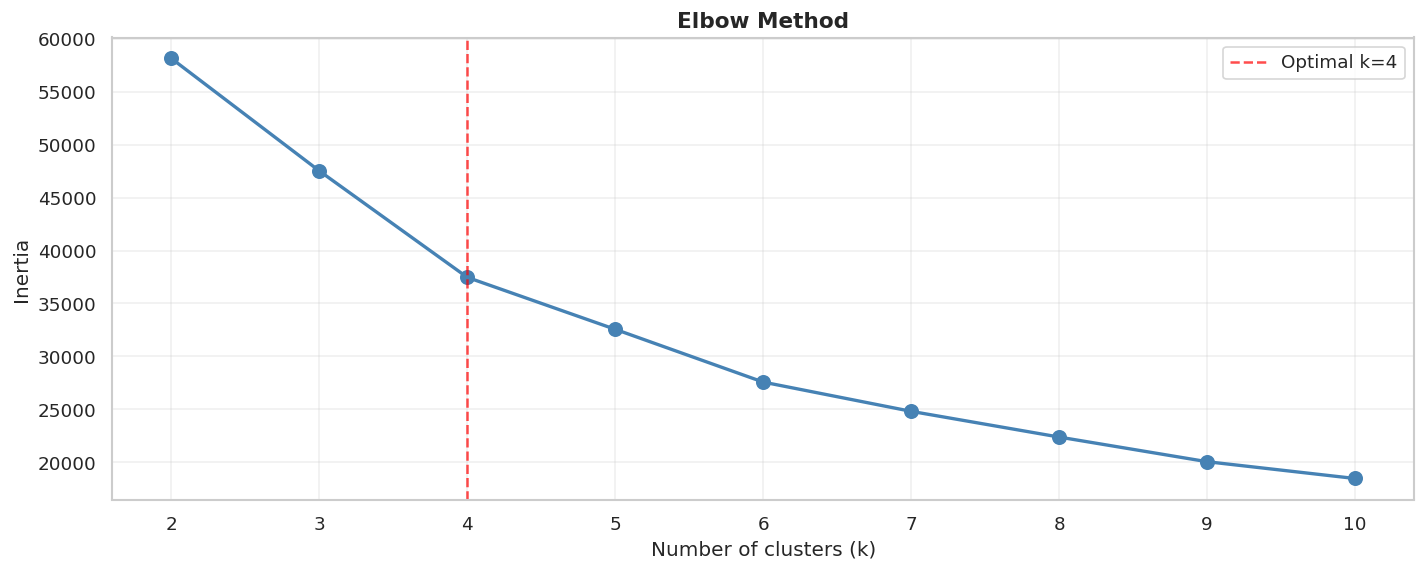

In [47]:
fig, ax = plt.subplots(figsize=(14, 5))

# Elbow curve
ax.plot(K_RANGE, inertias, 'o-', color='steelblue', markersize=8, linewidth=2)
ax.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal k=4')
ax.set_xlabel('Number of clusters (k)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax.set_xticks(K_RANGE)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

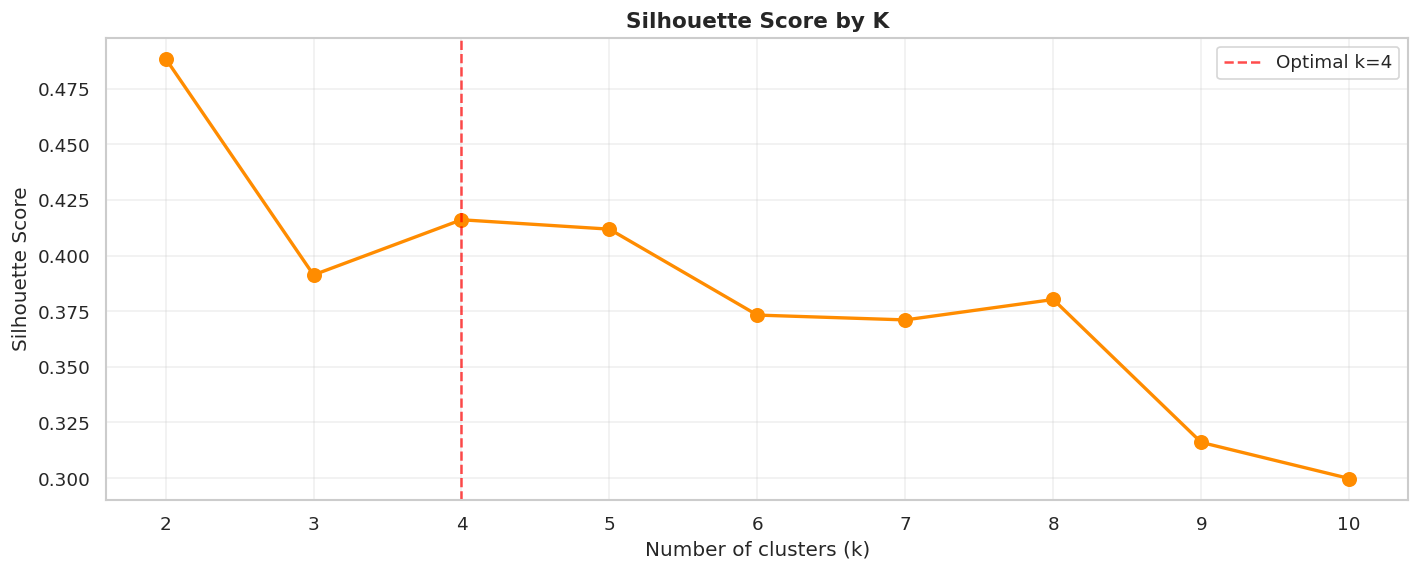

In [48]:
fig, ax = plt.subplots(figsize=(14, 5))

# Silhouette score plot
ax.plot(K_RANGE, silhouettes, 'o-', color='darkorange', markersize=8, linewidth=2)
ax.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal k=4')
ax.set_xlabel('Number of clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score by K', fontsize=13, fontweight='bold')
ax.set_xticks(K_RANGE)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

## 4. Apply K-Means with k=4

**Why k=4?**
Two convergent signals from the previous analysis:
- The **elbow** in the inertia curve appears at k=4
- The **Silhouette Score** at k=4 (0.41) is the second-best value after k=2,
  which would produce groups too broad to be useful for recommendations

K-Means will assign each of the 116,929 movies to one of 4 clusters
by minimizing the distance between each movie and its cluster centroid
in the 5-dimensional PCA space.

In [67]:
K_OPTIMO = 4

kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_pca)

df_clean['cluster'] = labels_kmeans

CLUSTER_NAMES = {
    0: 'Cult Cinema',
    1: 'Average Cinema',
    2: 'Classic Cinema',
    3: 'Blockbusters'
}
df_clean['cluster_name'] = df_clean['cluster'].map(CLUSTER_NAMES)

# Distribution table
dist = df_clean.groupby(['cluster', 'cluster_name']).size().reset_index(name='movies')
dist['percentage'] = (dist['movies'] / dist['movies'].sum() * 100).round(1)
dist.columns = ['Cluster', 'Name', 'Movies', 'Percentage (%)']

print(" Cluster Distribution:")
display(dist)

 Cluster Distribution:


,Cluster,Name,Movies,Percentage (%)
0,0,Cult Cinema,18874,16.1
1,1,Average Cinema,72297,61.8
2,2,Classic Cinema,24831,21.2
3,3,Blockbusters,927,0.8


## 5. Cluster Profile Analysis

Now that each movie has been assigned to a cluster, we analyze the **average
characteristics** of each group to understand what kind of movies they contain.

We look at:
- **Average rating** → quality perception
- **Average popularity** → audience reach
- **Average release year** → era of production
- **Average runtime** → film length
- **Average vote count** → how many users rated it

In [51]:


profile = df_clean.groupby('cluster_name').agg(
    Movies        = ('title',        'count'),
    Avg_Rating    = ('vote_average', 'mean'),
    Avg_Popularity= ('popularity',   'mean'),
    Avg_Year      = ('release_year', 'mean'),
    Avg_Runtime   = ('runtime',      'mean'),
    Avg_VoteCount = ('vote_count',   'mean')
).round(2).reset_index()

profile.columns = ['Cluster', 'Movies', 'Avg Rating', 'Avg Popularity',
                   'Avg Year', 'Avg Runtime (min)', 'Avg Vote Count']

print(" Cluster Profile:")
display(profile)

 Cluster Profile:


,Cluster,Movies,Avg Rating,Avg Popularity,Avg Year,Avg Runtime (min),Avg Vote Count
0,Average Cinema,72297,5.64,5.33,2005.82,97.93,114.92
1,Blockbusters,927,7.18,91.43,2008.75,119.36,8805.59
2,Classic Cinema,24831,5.83,2.56,1961.73,55.37,22.43
3,Cult Cinema,18874,7.54,6.66,2000.44,94.70,203.29


## 6. Top Movies per Cluster

To validate the clustering results, we inspect the most popular movies
in each group. This is a qualitative check: if the algorithm worked correctly,
movies within each cluster should feel intuitively similar.

Movies are sorted by popularity within each cluster.

In [72]:
for name in CLUSTER_NAMES.values():
    top = (df_clean[df_clean['cluster_name'] == name]
           [['title', 'vote_average', 'popularity', 'genres', 'release_year']]
           .sort_values('popularity', ascending=False)
           .head(15)
           .reset_index(drop=True))
    top.index += 1
    print(f"\n {name.upper()}")
    display(top)


 CULT CINEMA


,title,vote_average,popularity,genres,release_year
1,Special Delivery,7.200,277.460,"Action, Crime",2022.0
2,Murder City,7.400,262.437,"Crime, Thriller, Action",2023.0
3,PAW Patrol: The Mighty Movie,7.679,257.355,"Animation, Family, Comedy, Action, Science Fic...",2023.0
4,Creation of the Gods I: Kingdom of Storms,7.500,254.998,"Action, Fantasy, War",2023.0
5,The Seven Deadly Sins: Grudge of Edinburgh Part 2,7.309,240.649,"Action, Adventure, Fantasy, Animation",2023.0
6,Warhorse One,7.242,230.210,"Action, Drama, War",2023.0
7,PAW Patrol: The Movie,7.425,217.613,"Animation, Family, Adventure, Comedy",2021.0
8,"Miraculous: Ladybug & Cat Noir, The Movie",7.800,212.626,"Animation, Music, Family, Action, Romance, Fan...",2023.0
9,Mavka: The Forest Song,7.375,206.792,"Animation, Adventure, Family, Fantasy",2023.0
10,Taboo II,8.000,197.988,"Drama, Romance",1982.0



 AVERAGE CINEMA


,title,vote_average,popularity,genres,release_year
1,Spirit of Fear,6.909,260.442,Horror,2023.0
2,I Am Rage,6.737,254.408,"Action, Thriller, Horror",2023.0
3,The White Storm 3: Heaven or Hell,7.000,246.471,"Action, Drama, Crime",2023.0
4,Mob Land,5.800,242.638,"Action, Crime, Thriller",2023.0
5,Piglady,4.000,232.921,"Horror, Crime",2023.0
6,All Ladies Do It,4.800,232.565,"Comedy, Drama",1992.0
7,Paydirt,5.925,227.981,"Action, Crime, Thriller",2020.0
8,Sympathy for the Devil,6.306,225.659,"Action, Thriller",2023.0
9,American Psycho II: All American Girl,4.500,225.504,"Horror, Thriller",2002.0
10,Cobweb,6.911,208.069,Horror,2023.0



 CLASSIC CINEMA


,title,vote_average,popularity,genres,release_year
1,Deep Throat,5.307,157.534,Comedy,1972.0
2,Saw,7.000,115.188,"Crime, Horror, Thriller",2003.0
3,The Party at Kitty and Stud's,3.557,111.601,"Comedy, Drama",1970.0
4,My Hero Academia: All Might Rising,6.850,98.305,"Animation, Action",2019.0
5,Maid in Sweden,4.400,95.616,Drama,1971.0
6,I Miss Sonia Henie,5.765,65.706,"Comedy, Drama",1971.0
7,Dumbo,6.995,60.157,"Animation, Family",1941.0
8,Dragon Ball GT: A Hero's Legacy,6.747,56.565,"Animation, Family, Fantasy",1997.0
9,Dragon Ball Z: Broly – Second Coming,6.697,54.021,"Animation, Action, Science Fiction",1994.0
10,Debbie Does Dallas,6.329,48.510,Comedy,1978.0



 BLOCKBUSTERS


,title,vote_average,popularity,genres,release_year
1,Blue Beetle,7.139,2994.357,"Action, Science Fiction, Adventure",2023.0
2,Gran Turismo,8.068,2680.593,"Action, Drama, Adventure",2023.0
3,A Female Boss with Big Tits and Her Cherry Boy...,9.000,2020.286,Drama,2020.0
4,The Nun II,6.545,1692.778,"Horror, Mystery, Thriller",2023.0
5,Meg 2: The Trench,6.912,1567.273,"Action, Science Fiction, Horror",2023.0
6,Retribution,6.816,1547.220,"Action, Mystery, Thriller, Crime",2023.0
7,Talk to Me,7.214,1458.514,"Horror, Thriller",2023.0
8,Fast X,7.265,1175.267,"Action, Crime, Thriller",2023.0
9,Sound of Freedom,7.973,1111.036,"Action, Drama",2023.0
10,Barbie,7.279,1069.340,"Comedy, Adventure, Fantasy",2023.0


## 7. Evaluation Metrics

We use three internal metrics to objectively evaluate the quality of the clustering.
These metrics do not require labeled data — they measure the internal structure
of the clusters themselves.

| Metric | What it measures | Better when |
|--------|-----------------|-------------|
| **Silhouette Score** | How well separated the clusters are | Closer to 1 |
| **Davies-Bouldin Index** | Compactness and separation of clusters | Closer to 0 |


In [75]:
sil = silhouette_score(X_pca, labels_kmeans, sample_size=5000, random_state=42)
db  = davies_bouldin_score(X_pca, labels_kmeans)

metrics_df = pd.DataFrame({
    'Metric':      ['Silhouette Score', 'Davies-Bouldin Index'],
    'Value':       [round(sil, 4), round(db, 4)],
    'Best when':   ['Closer to 1', 'Closer to 0'],
    'Interpretation': [
        'Moderate separation between clusters',
        'Clusters are compact and well separated',

    ]
})

print(" K-Means Evaluation Metrics (k=4):")
display(metrics_df)

 K-Means Evaluation Metrics (k=4):


,Metric,Value,Best when,Interpretation
0,Silhouette Score,0.3994,Closer to 1,Moderate separation between clusters
1,Davies-Bouldin Index,1.0178,Closer to 0,Clusters are compact and well separated


## 8. Visualizations

Four plots to understand the clustering results:

1. **Scatter PC1 vs PC2** — spatial distribution of clusters in the two most
   important dimensions. Each dot is a movie, colored by cluster.


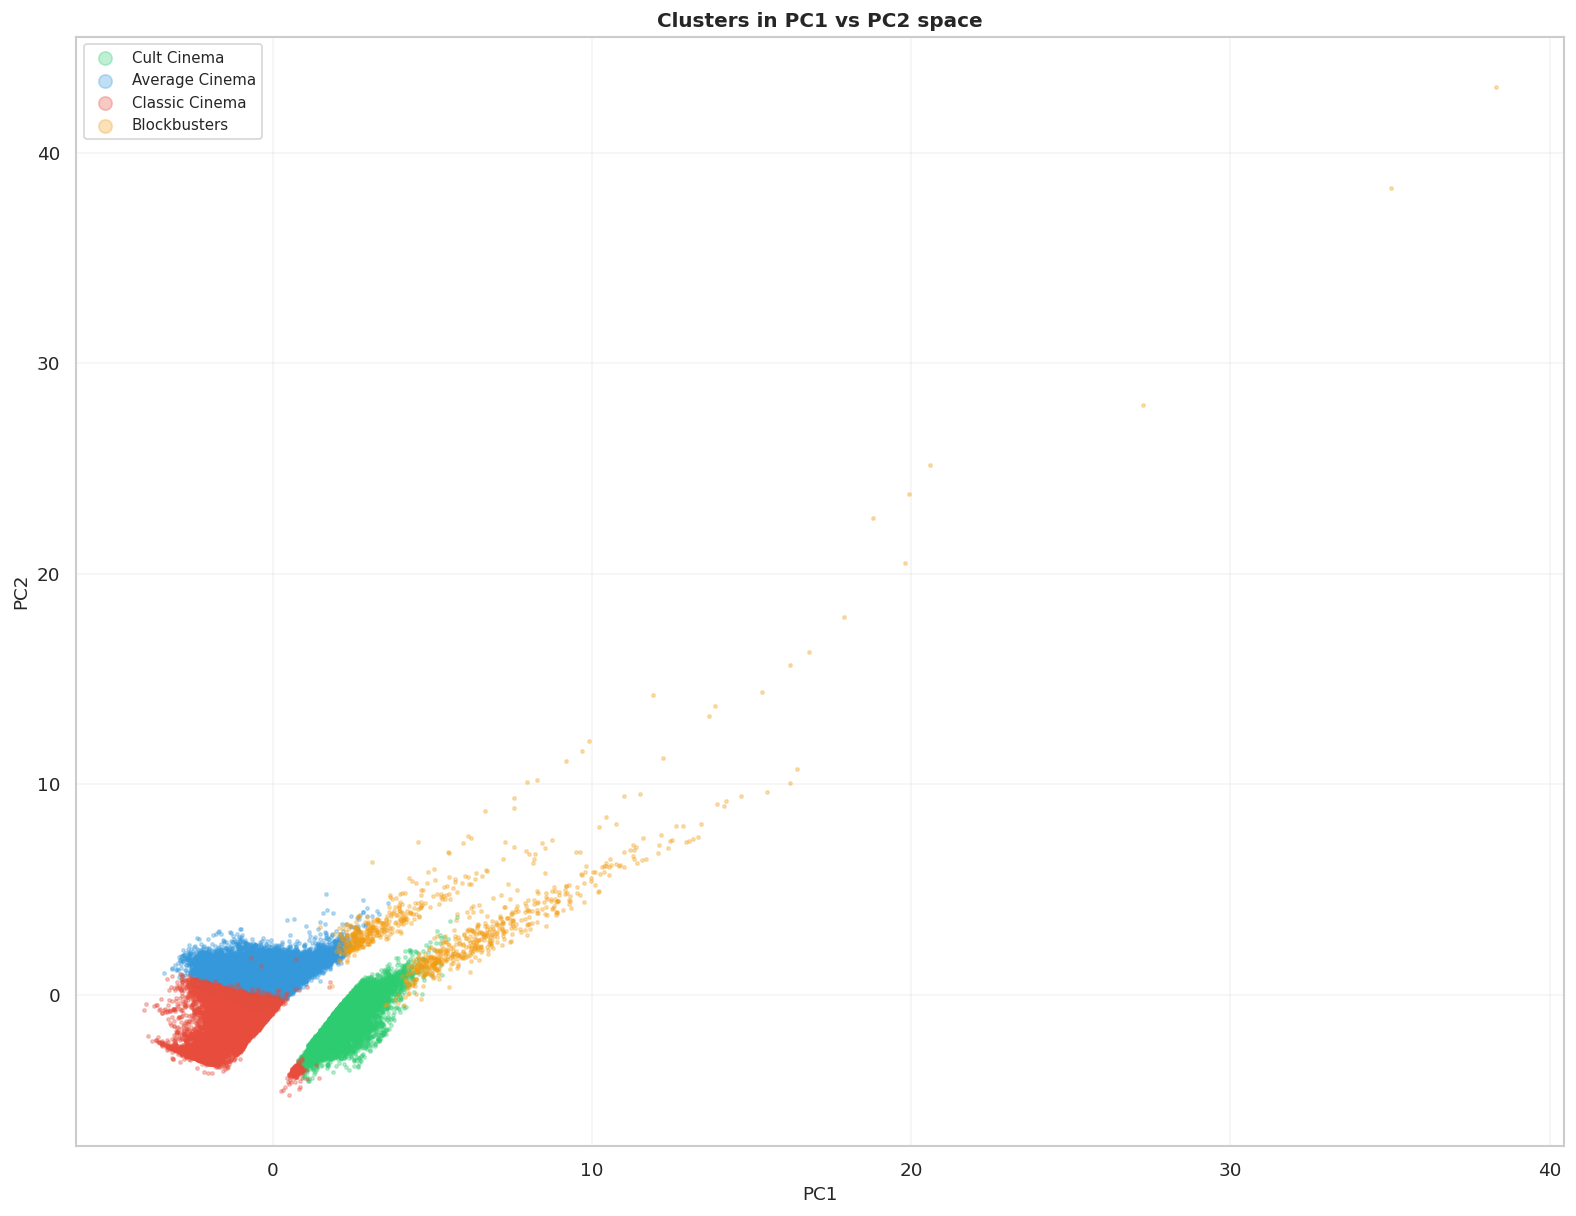

In [76]:
COLORS = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
COLOR_MAP = {name: COLORS[i] for i, name in enumerate(CLUSTER_NAMES.values())}

fig, ax = plt.subplots( figsize=(16, 12))


for i, name in enumerate(CLUSTER_NAMES.values()):
    mask = df_clean['cluster_name'] == name
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      c=COLORS[i], label=name, alpha=0.3, s=4)
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_title('Clusters in PC1 vs PC2 space', fontsize=12, fontweight='bold')
ax.legend(markerscale=4, fontsize=9)
ax.grid(alpha=0.2)
plt.show()

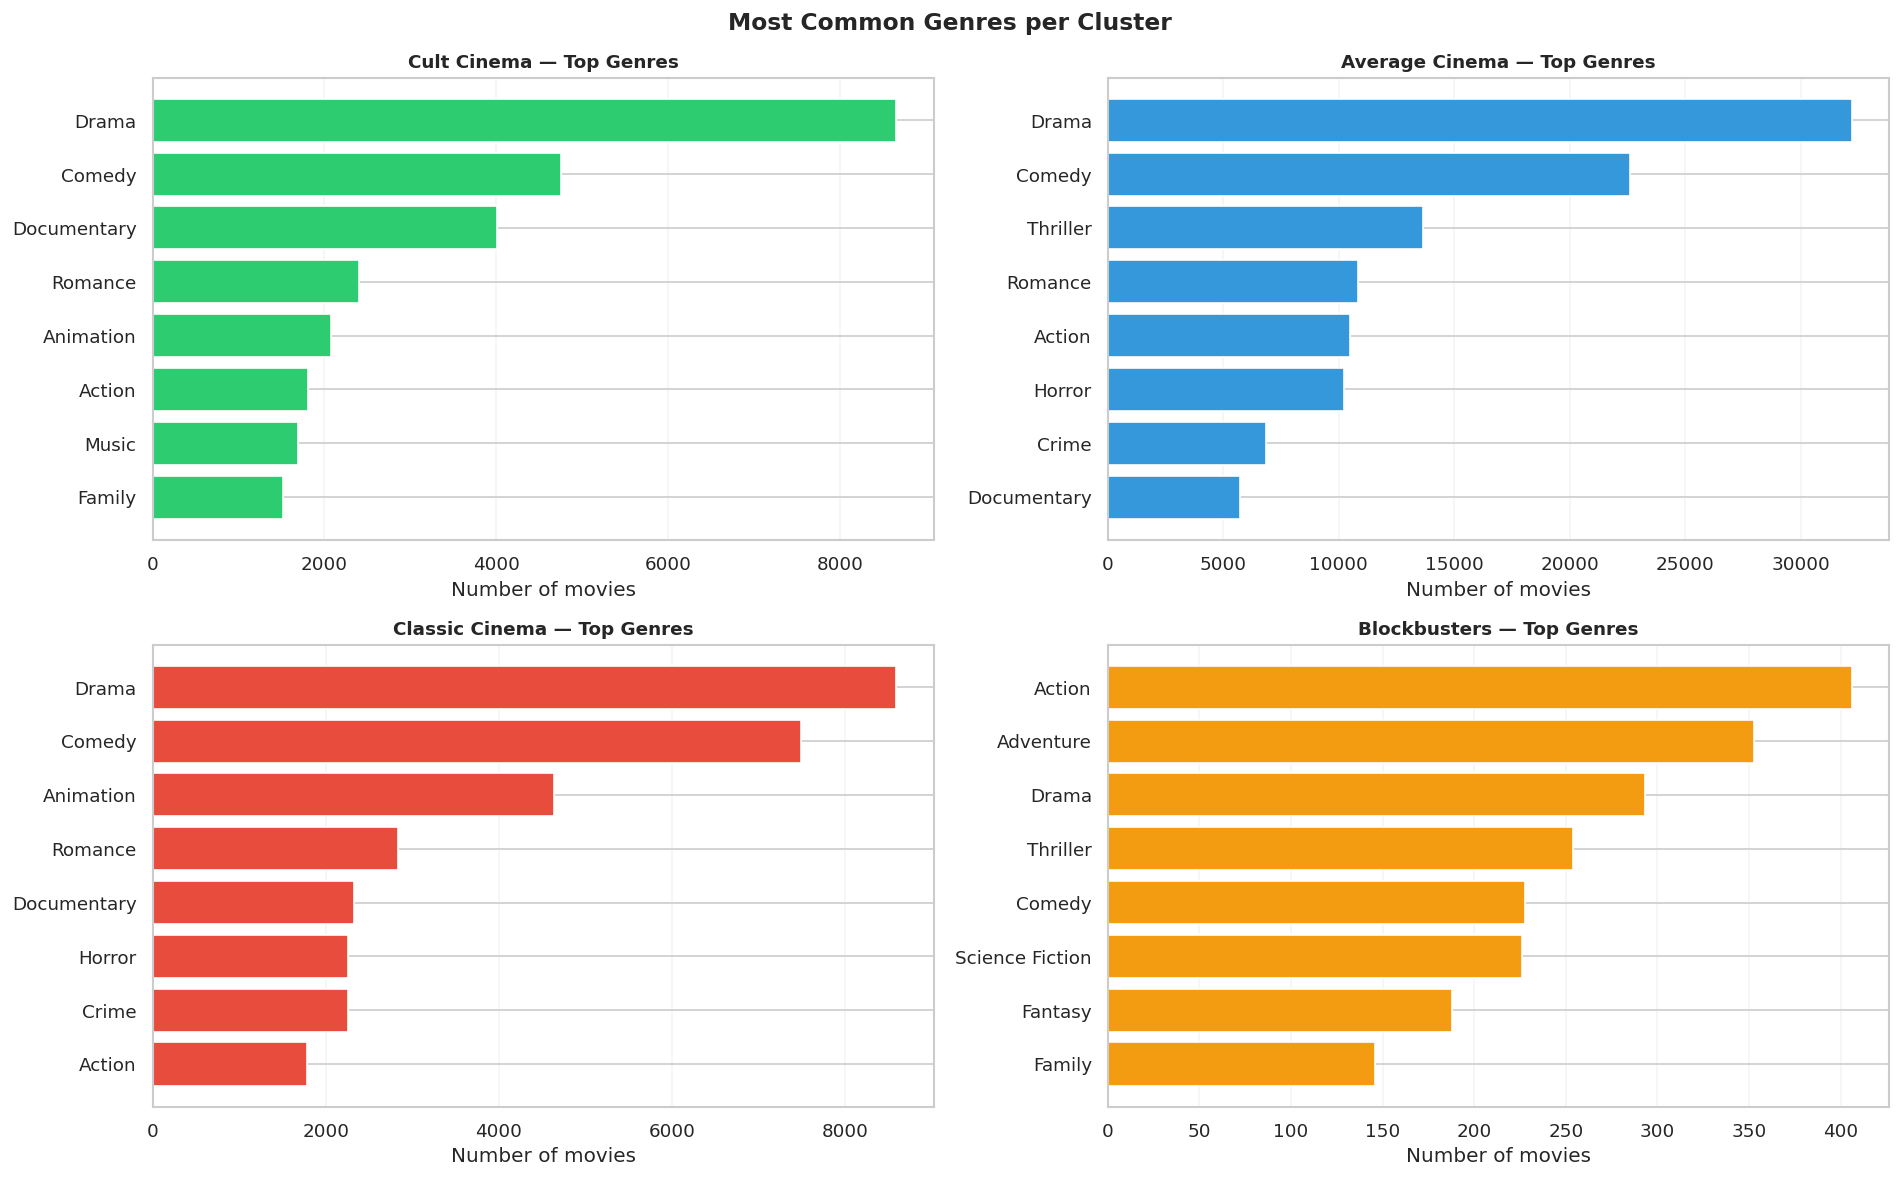

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, name in enumerate(CLUSTER_NAMES.values()):
    subset = df_clean[df_clean['cluster_name'] == name]['genres'].dropna()
    all_genres = subset.str.split(', ').explode()
    top_genres = all_genres.value_counts().head(8)

    axes[i].barh(top_genres.index[::-1], top_genres.values[::-1], color=COLORS[i])
    axes[i].set_title(f'{name} — Top Genres', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Number of movies')
    axes[i].grid(alpha=0.2, axis='x')

plt.suptitle('Most Common Genres per Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Genre Analysis per Cluster

Beyond numerical features, we analyze which **genres dominate each cluster**.
This adds an interpretability layer: if the Blockbuster cluster is dominated
by Action and Adventure, that confirms the algorithm captured meaningful
cinematic patterns — not just statistical noise.

In [66]:
summary = pd.DataFrame({
    'Cluster':        list(CLUSTER_NAMES.values()),
    'Movies':         [18874, 72297, 24831, 927],
    'Pct (%)':        [16.1, 61.8, 21.2, 0.8],
    'Avg Rating':     [7.54, 5.64, 5.83, 7.18],
    'Avg Popularity': [6.66, 5.33, 2.56, 91.43],
    'Avg Year':       [2000, 2005, 1961, 2008],
    'Silhouette':     [sil]*4,
    'Davies-Bouldin': [db]*4,
    'Calinski-H':     [round(ch,1)]*4
})

print(" FINAL SUMMARY — K-MEANS k=4 — TMDB DATASET")
display(summary)

 FINAL SUMMARY — K-MEANS k=4 — TMDB DATASET


,Cluster,Movies,Pct (%),Avg Rating,Avg Popularity,Avg Year,Silhouette,Davies-Bouldin,Calinski-H
0,Cult Cinema,18874,16.1,7.54,6.66,2000,0.399402,1.017828,38033.8
1,Average Cinema,72297,61.8,5.64,5.33,2005,0.399402,1.017828,38033.8
2,Classic Cinema,24831,21.2,5.83,2.56,1961,0.399402,1.017828,38033.8
3,Blockbusters,927,0.8,7.18,91.43,2008,0.399402,1.017828,38033.8


## 10. Recommendation Function

This is the practical application of the clustering analysis.

**How it works:**
1. User inputs a movie title
2. The function finds its cluster
3. Filters all movies in that same cluster
4. Computes **Euclidean distance** in the PCA space between the input movie
   and every other movie in the cluster
5. Returns the 5 closest movies as recommendations

**Why Euclidean distance?**
Two movies with similar PC1–PC5 values had similar ratings, popularity,
runtime and release patterns. The closer they are in PCA space,
the more alike they are as cinematic products.

This approach is **scalable**: instead of comparing against 116,929 movies,
we only search within the cluster — reducing the search space by up to 98%.

In [82]:

from sklearn.metrics.pairwise import euclidean_distances

def recommend_movies(title, df, n=5):
    """
    Given a movie title, returns the n most similar movies
    within the same K-Means cluster.

    Parameters:
        title : str   — movie title to search
        df    : DataFrame — must have cluster, PCA cols and metadata
        n     : int   — number of recommendations
    """

    # 1. Find the movie
    match = df[df['title'].str.lower() == title.lower()]

    if match.empty:
        # Try partial match
        match = df[df['title'].str.lower().str.contains(title.lower())]
        if match.empty:
            print(f" Movie '{title}' not found in dataset.")
            return

    movie = match.iloc[0]
    cluster_id   = movie['cluster']
    cluster_name = movie['cluster_name']

    print(f"\n Movie found: {movie['title']}")
    print(f"   Cluster: {cluster_id} — {cluster_name}")
    print(f"   Rating: {movie['vote_average']} | Popularity: {movie['popularity']:.1f} | Year: {int(movie['release_year'])}")
    print(f"   Genres: {movie['genres']}")

    same_cluster = df[
        (df['cluster'] == cluster_id) &
        (df['title'] != movie['title'])
    ].copy()


    movie_vector   = movie[PCA_COLS].values.reshape(1, -1)
    cluster_matrix = same_cluster[PCA_COLS].values
    distances      = euclidean_distances(movie_vector, cluster_matrix)[0]
    same_cluster['distance'] = distances

    top_n = (same_cluster
             .sort_values('distance')
             .head(n)[['title', 'vote_average', 'popularity', 'genres', 'release_year', 'distance']]
             .reset_index(drop=True))
    top_n.index += 1
    top_n.columns = ['Title', 'Rating', 'Popularity', 'Genres', 'Year', 'Distance (similarity)']
    top_n['Year'] = top_n['Year'].astype(int)
    top_n['Distance (similarity)'] = top_n['Distance (similarity)'].round(3)

    print(f"\n Top {n} recommendations from the same cluster ({cluster_name}):")
    display(top_n)
    print(f"\nAll {len(same_cluster):,} movies in this cluster are candidates for recommendation.")

In [83]:
recommend_movies("Inception", df_clean)


 Movie found: Inception
   Cluster: 3 — Blockbusters
   Rating: 8.364 | Popularity: 84.0 | Year: 2010
   Genres: Action, Science Fiction, Adventure

 Top 5 recommendations from the same cluster (Blockbusters):


,Title,Rating,Popularity,Genres,Year,Distance (similarity)
1,Interstellar,8.417,140.241,"Adventure, Drama, Science Fiction",2014,3.271
2,The Dark Knight,8.512,130.643,"Drama, Action, Crime, Thriller",2008,4.497
3,Avatar,7.573,79.932,"Action, Adventure, Fantasy, Science Fiction",2009,4.845
4,The Avengers,7.710,98.082,"Science Fiction, Action, Adventure",2012,5.517
5,Deadpool,7.606,72.735,"Action, Adventure, Comedy",2016,5.919



All 926 movies in this cluster are candidates for recommendation.


In [84]:
recommend_movies("Toy Story", df_clean)


 Movie found: Toy Story
   Cluster: 3 — Blockbusters
   Rating: 7.971 | Popularity: 78.4 | Year: 1995
   Genres: Animation, Adventure, Family, Comedy

 Top 5 recommendations from the same cluster (Blockbusters):


,Title,Rating,Popularity,Genres,Year,Distance (similarity)
1,The Lion King,8.256,87.384,"Family, Animation, Drama",1994,0.536
2,"Monsters, Inc.",7.835,86.936,"Animation, Comedy, Family",2001,0.566
3,WALL·E,8.078,58.517,"Animation, Family, Science Fiction",2008,1.184
4,The Incredibles,7.704,62.609,"Action, Adventure, Animation, Family",2004,1.438
5,Finding Nemo,7.824,55.456,"Animation, Family",2003,1.540



All 926 movies in this cluster are candidates for recommendation.


In [85]:
recommend_movies("Casablanca", df_clean)


 Movie found: Casablanca
   Cluster: 0 — Cult Cinema
   Rating: 8.171 | Popularity: 25.2 | Year: 1943
   Genres: Drama, Romance

 Top 5 recommendations from the same cluster (Cult Cinema):


,Title,Rating,Popularity,Genres,Year,Distance (similarity)
1,Dr. Strangelove or: How I Learned to Stop Worr...,8.129,18.253,"Drama, Comedy, War",1964,0.908
2,Lady and the Tramp,7.101,36.117,"Family, Animation, Romance",1955,1.254
3,Breakfast at Tiffany's,7.676,21.540,"Comedy, Romance, Drama",1961,1.385
4,It's a Wonderful Life,8.260,26.492,"Drama, Family, Fantasy",1946,1.396
5,A Fistful of Dollars,7.848,29.315,Western,1964,1.468



All 18,873 movies in this cluster are candidates for recommendation.


In [89]:
recommend_movies("he Dark Knig", df_clean)


 Movie found: The Dark Knight
   Cluster: 3 — Blockbusters
   Rating: 8.512 | Popularity: 130.6 | Year: 2008
   Genres: Drama, Action, Crime, Thriller

 Top 5 recommendations from the same cluster (Blockbusters):


,Title,Rating,Popularity,Genres,Year,Distance (similarity)
1,Interstellar,8.417,140.241,"Adventure, Drama, Science Fiction",2014,2.126
2,The Avengers,7.710,98.082,"Science Fiction, Action, Adventure",2012,2.177
3,Avatar,7.573,79.932,"Action, Adventure, Fantasy, Science Fiction",2009,2.517
4,Avengers: Infinity War,8.255,154.340,"Adventure, Action, Science Fiction",2018,3.192
5,Deadpool,7.606,72.735,"Action, Adventure, Comedy",2016,3.489



All 926 movies in this cluster are candidates for recommendation.
